### DataViz

In [1]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib as plt

np.random.seed(42)

In [5]:
import sys
sys.path.append("..")

In [6]:
from dataviz.dataviz_package import DataViz, analyze

In [7]:
data = {
    'product': ['A', 'B', 'C', 'D', 'E'] * 40,
    'sales': np.random.normal(100, 25, 200),
    'price': np.random.uniform(10, 100, 200),
    'quantity': np.random.randint(1, 50, 200),
    'region': np.random.choice(['North', 'South', 'East', 'West'], 200),
    'rating': np.random.uniform(1, 5, 200),
    'category': np.random.choice(['Electronics', 'Clothing', 'Food'], 200)
}

In [8]:
# Add some missing values
data['sales'][np.random.choice(200, 10, replace=False)] = np.nan
data['rating'][np.random.choice(200, 5, replace=False)] = np.nan


In [9]:
df = pd.DataFrame(data)
# print("Sample dataset created!")
print(f"Shape: {df.shape}")

Shape: (200, 7)


In [11]:
dv = analyze(df)

In [12]:
dv.show()          # View data

,product,sales,price,quantity,region,rating,category
0,A,112.417854,88.963576,49,West,1.207294,Food
1,B,96.543392,76.669176,25,South,2.346417,Electronics
2,C,116.192213,72.731417,33,North,1.537659,Food
3,D,138.075746,73.223568,38,South,1.253500,Electronics
4,E,94.146166,42.354204,6,North,4.959841,Clothing
5,A,94.146576,36.423266,44,South,2.289415,Clothing
6,B,139.480320,82.842504,45,North,4.239498,Electronics
7,C,NaN,82.910206,32,North,2.018563,Food
8,D,88.263140,88.036509,45,North,3.726011,Electronics
9,E,113.564001,92.191650,47,West,4.040911,Food


In [13]:
dv.insights()      # Get insights

🎨 Generating Automatic Visualizations...

📊 Correlation Heatmap


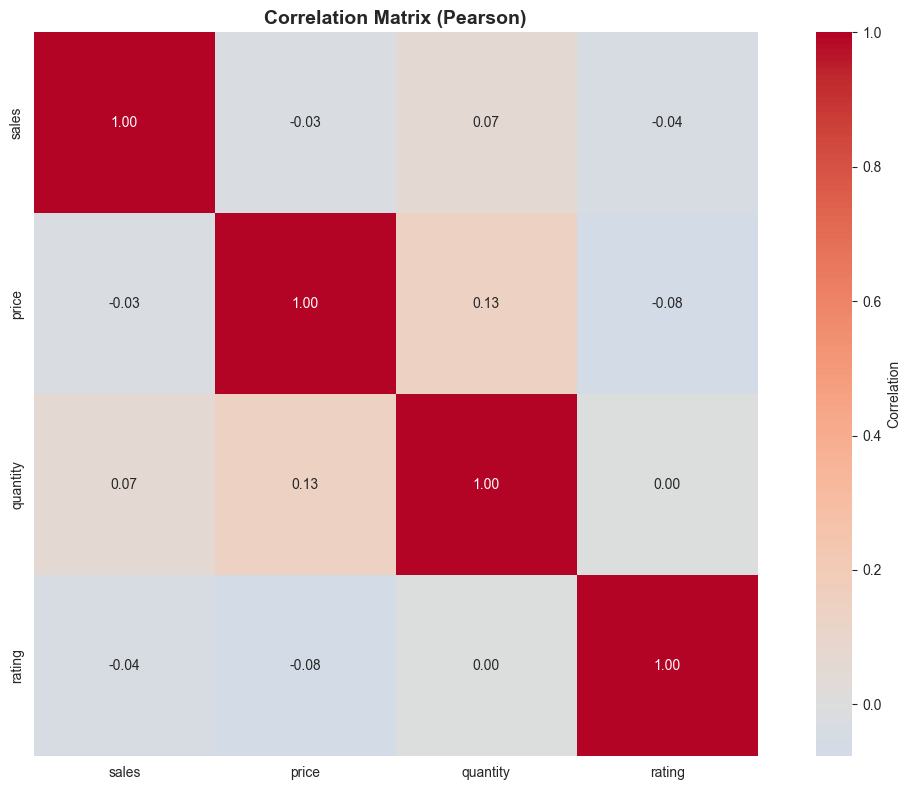

📊 Distribution of sales


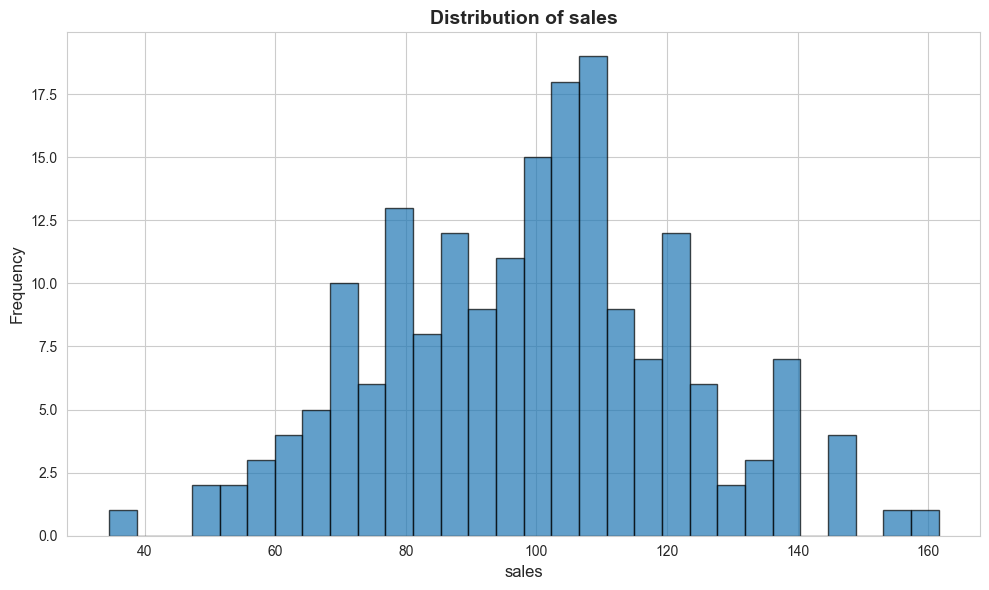

📊 Distribution of price


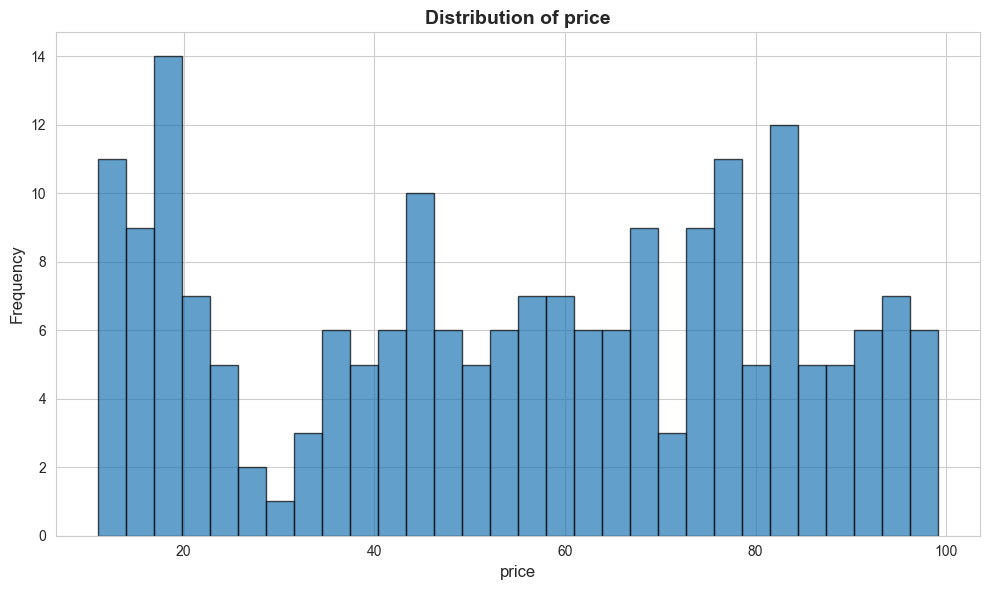

📊 Category Distribution of product


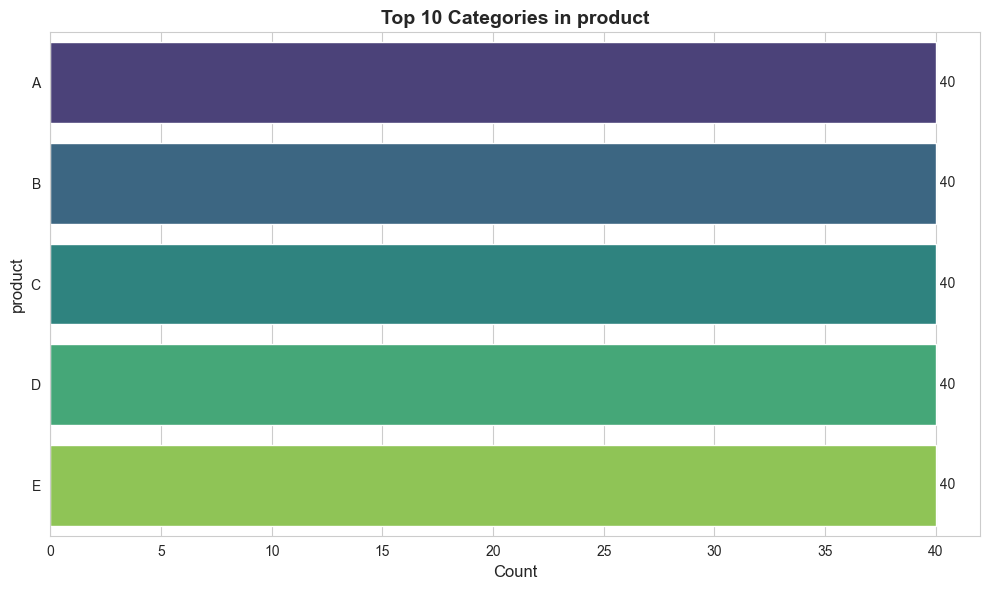

📊 Category Distribution of region


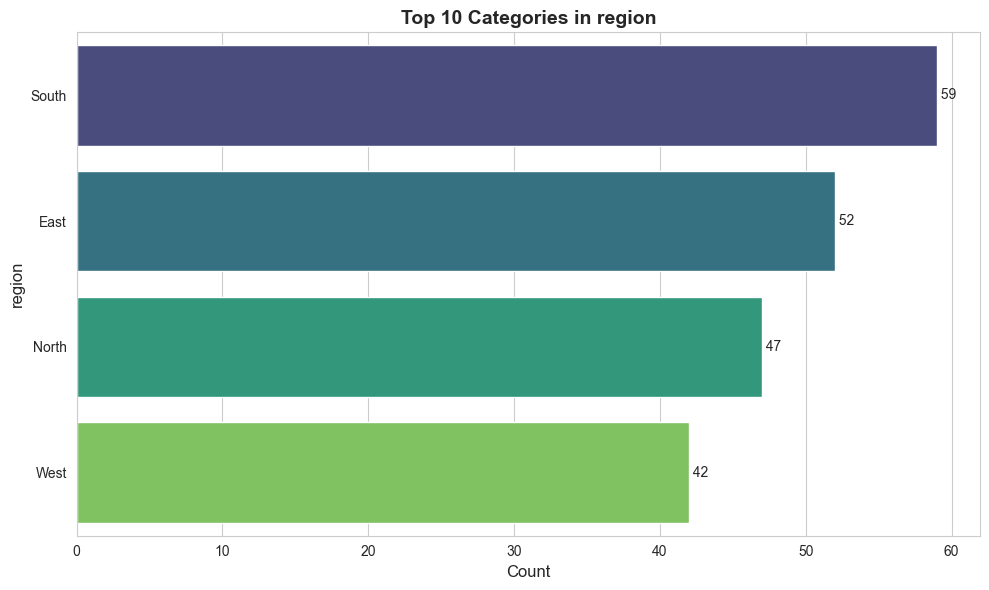

📊 Scatter Plot - price vs quantity


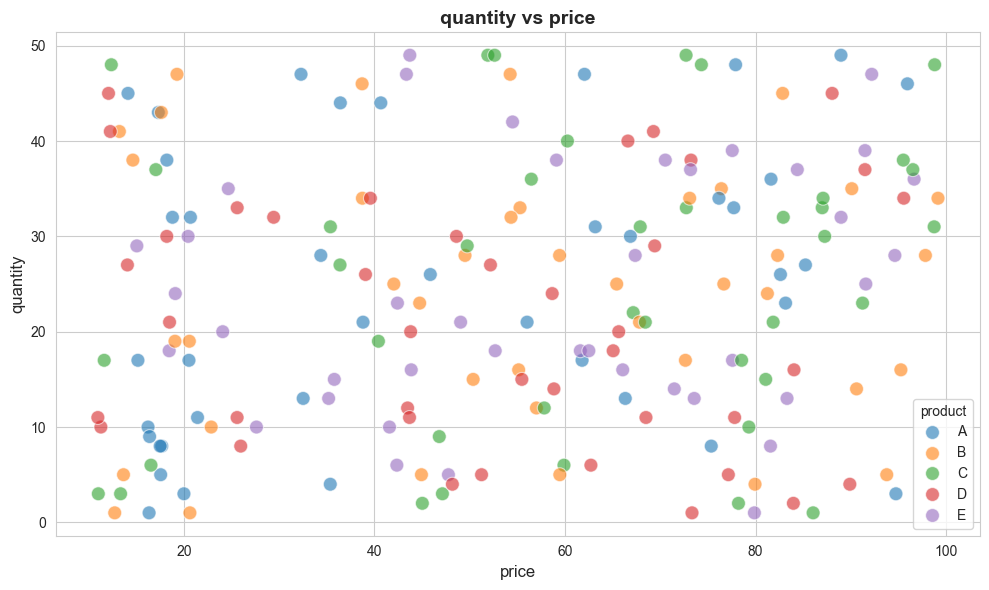

📊 Pairplot Analysis


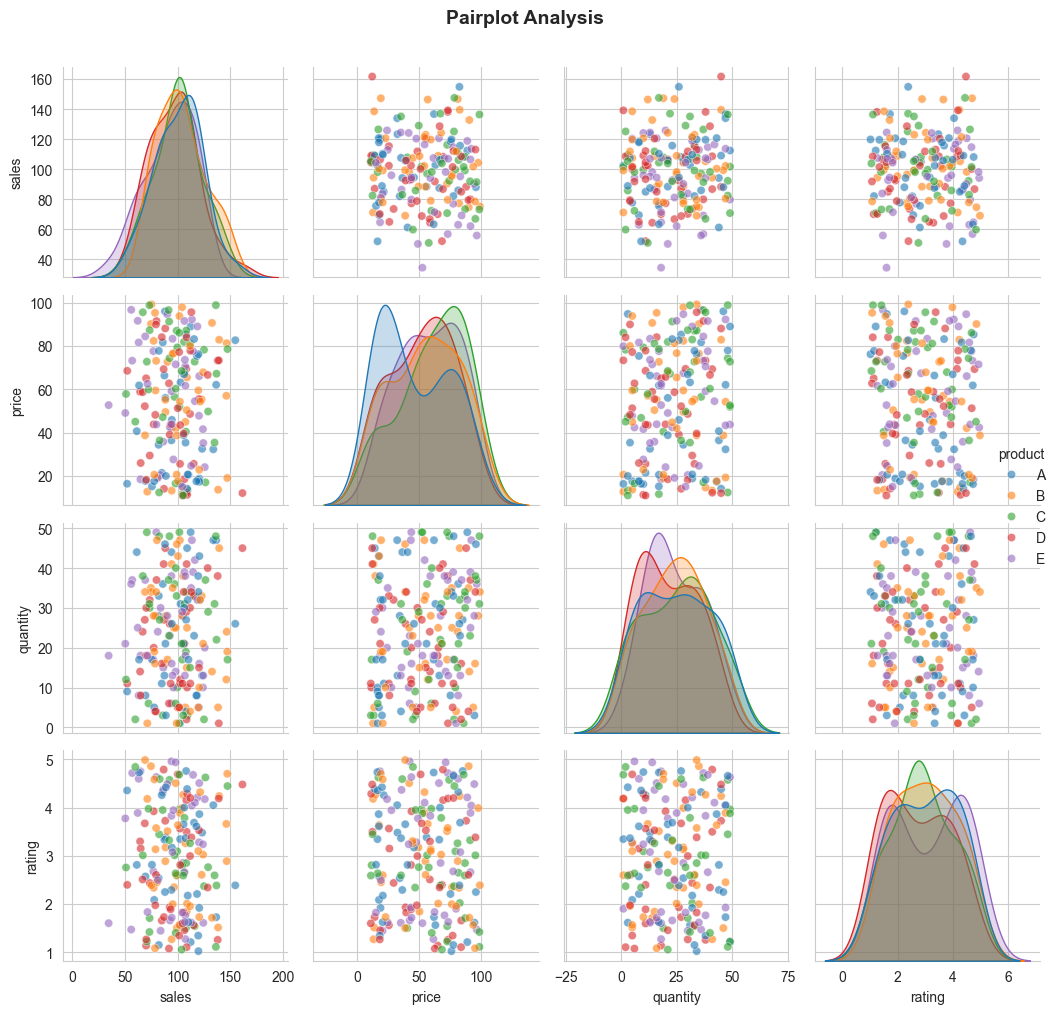


✅ Visualization complete!


In [14]:
dv.visualize()     # Chart recommendations

In [15]:
# Filter and analyze
dv_filtered = DataViz(df)
dv_filtered.filter(df['sales'] > 100)
print(f"Filtered dataset has {dv_filtered.df.shape[0]} rows")
dv_filtered.insights()

Filtered dataset has 96 rows


In [16]:
# Check data quality issues
print("=" * 50)
print("DATA QUALITY SUMMARY")
print("=" * 50)
print(f"Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nData types:")
print(df.dtypes)
print(f"\nNumeric columns summary:")
print(df.describe())

DATA QUALITY SUMMARY
Missing values per column:
sales     10
rating     5
dtype: int64

Data types:
product      object
sales       float64
price       float64
quantity      int32
region       object
rating      float64
category     object
dtype: object

Numeric columns summary:
            sales       price    quantity      rating
count  190.000000  200.000000  200.000000  195.000000
mean    98.679609   54.669204   23.925000    2.962085
std     22.908113   26.692874   14.028305    1.157686
min     34.506372   10.975389    1.000000    1.018528
25%     82.038225   32.465343   12.000000    1.893154
50%    100.226442   56.243924   24.000000    2.888268
75%    112.328843   77.736290   34.250000    3.970134
max    161.581053   99.145463   49.000000    4.987497


Sales Analytics Dashboard


,date,revenue,customers,conversion_rate,marketing_spend
0,2024-01-01,12668.296668,151,0.029435,762.954414
1,2024-01-02,13820.517184,54,0.020271,1535.007336
2,2024-01-03,10476.813723,135,0.021395,801.400533
3,2024-01-04,12443.781590,83,0.022292,1303.741527
4,2024-01-05,8667.587329,104,0.042121,645.014674
5,2024-01-06,14748.002714,168,0.031566,1175.556404
6,2024-01-07,12289.091038,163,0.022452,1634.244993
7,2024-01-08,18230.812604,194,0.034413,1021.357286
8,2024-01-09,12643.532572,75,0.038646,1497.367587
9,2024-01-10,11867.112200,185,0.020905,1693.174941


🎨 Generating Automatic Visualizations...

📊 Correlation Heatmap


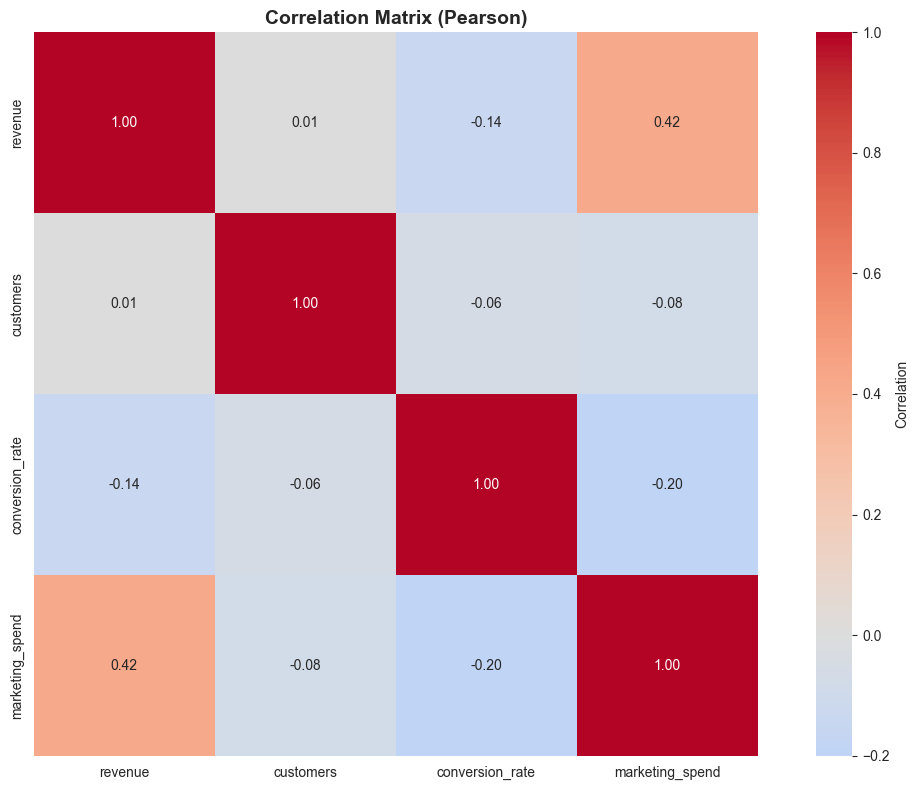

📊 Distribution of revenue


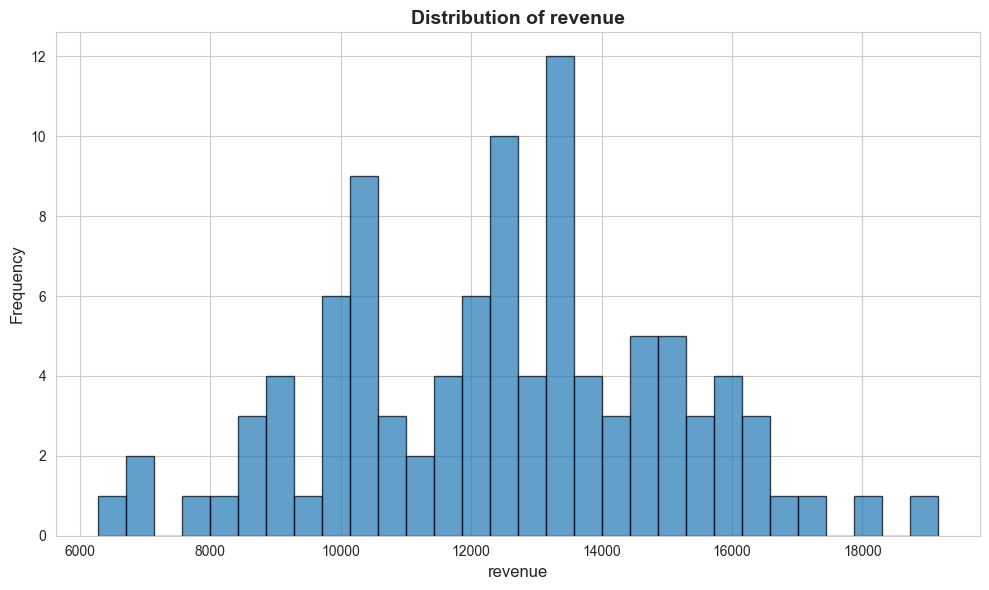

📊 Distribution of customers


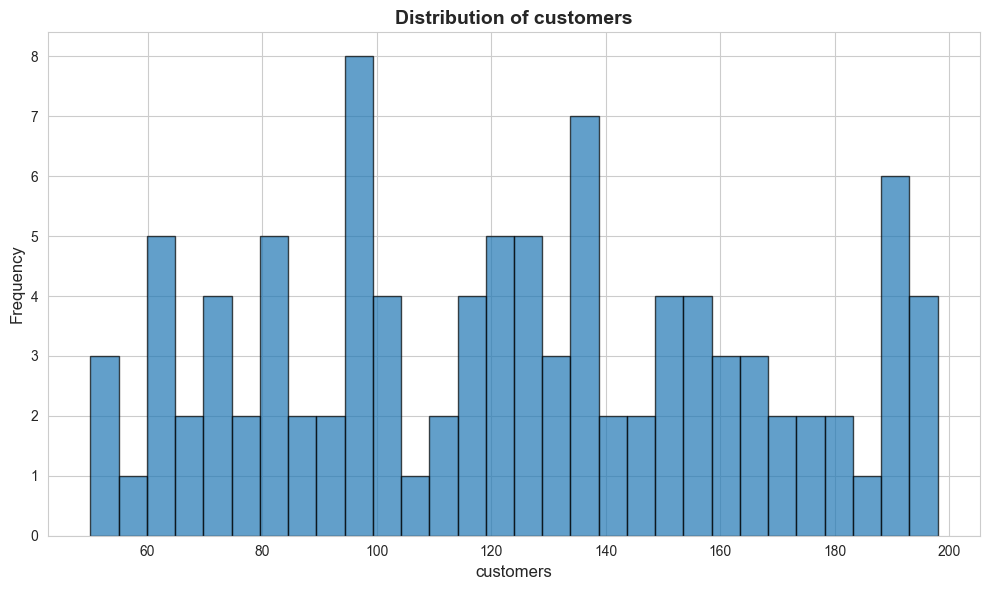

📊 Scatter Plot - revenue vs marketing_spend


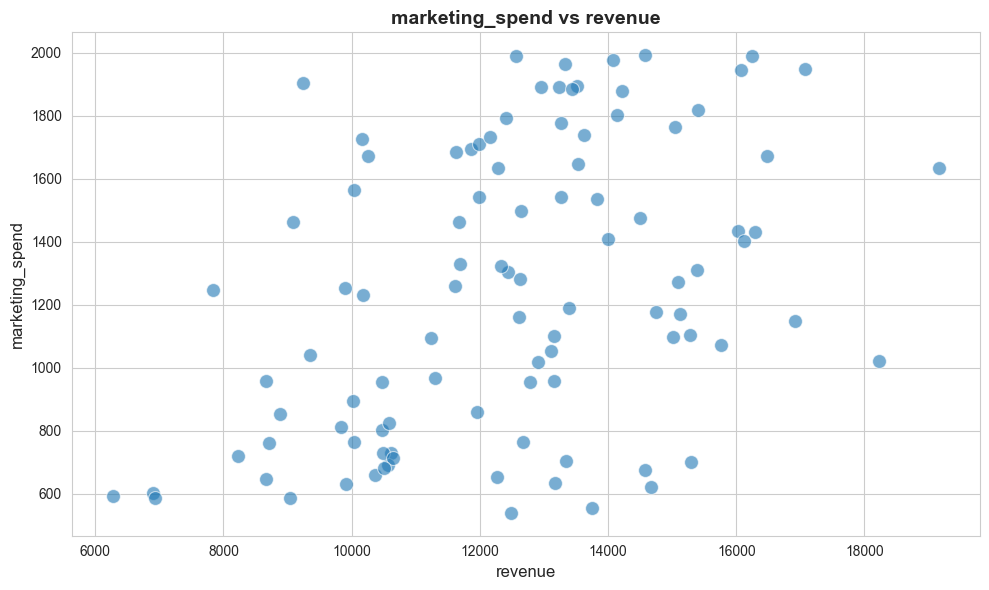

📊 Pairplot Analysis


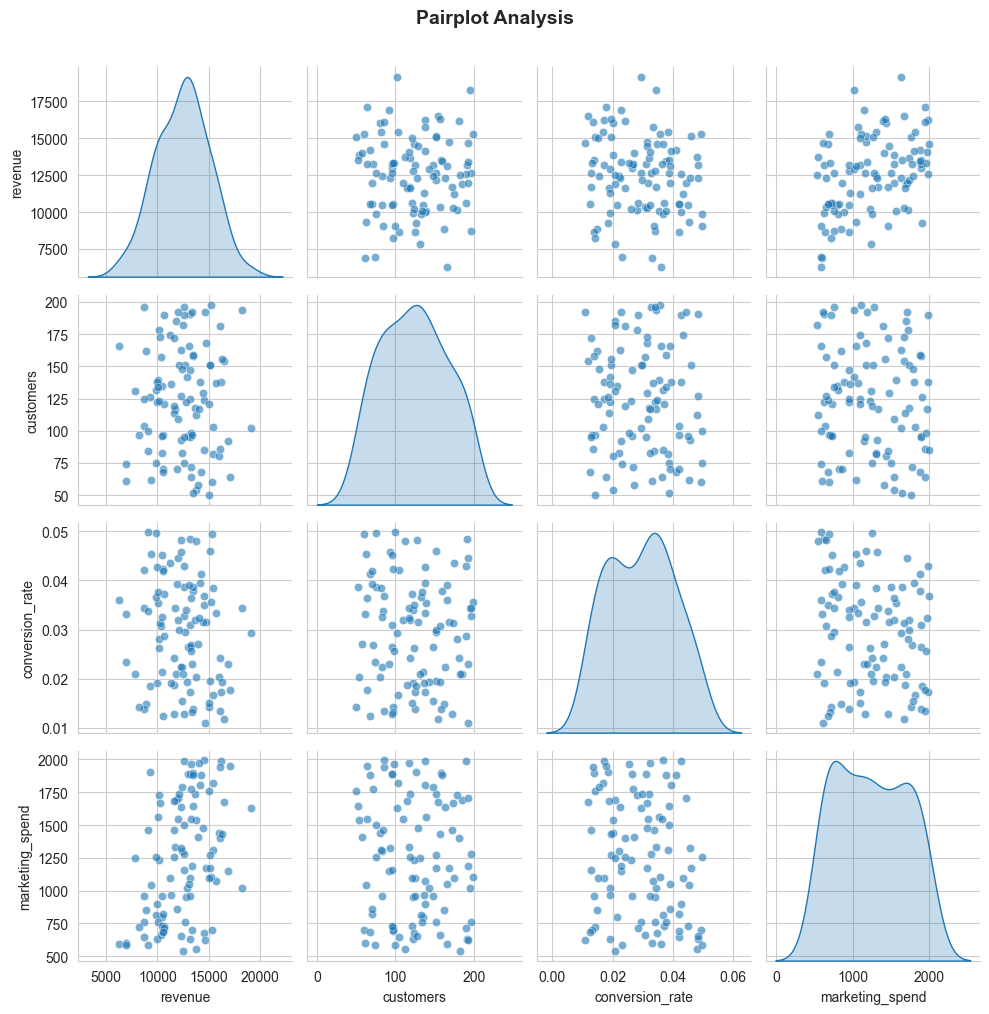


✅ Visualization complete!


In [17]:
# Create a more complex dataset
sales_data = pd.DataFrame({
    'date': pd.date_range('2024-01-01', periods=100, freq='D'),
    'revenue': np.random.normal(10000, 2000, 100),
    'customers': np.random.randint(50, 200, 100),
    'conversion_rate': np.random.uniform(0.01, 0.05, 100),
    'marketing_spend': np.random.uniform(500, 2000, 100)
})

# Add correlation
sales_data['revenue'] = sales_data['revenue'] + sales_data['marketing_spend'] * 2

dv_sales = DataViz(sales_data)
print("Sales Analytics Dashboard")
dv_sales.show()
dv_sales.insights()
dv_sales.visualize()

 \VISUALIZATION EXAMPLES


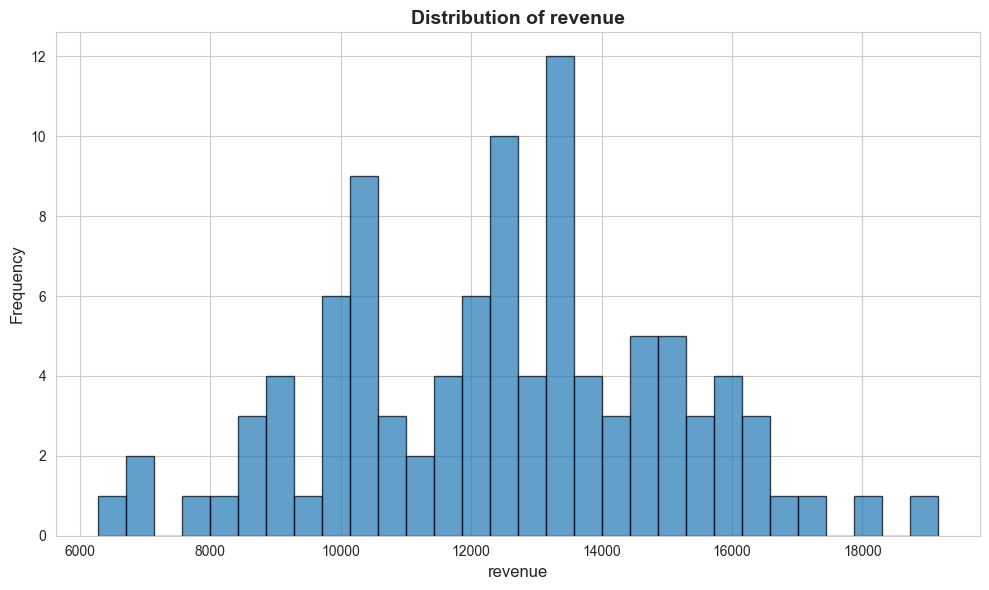

In [18]:
# Individual Plot Methods
print(" \VISUALIZATION EXAMPLES")

# Distribution plot
dv_sales.plot_distribution('revenue', kind='hist')

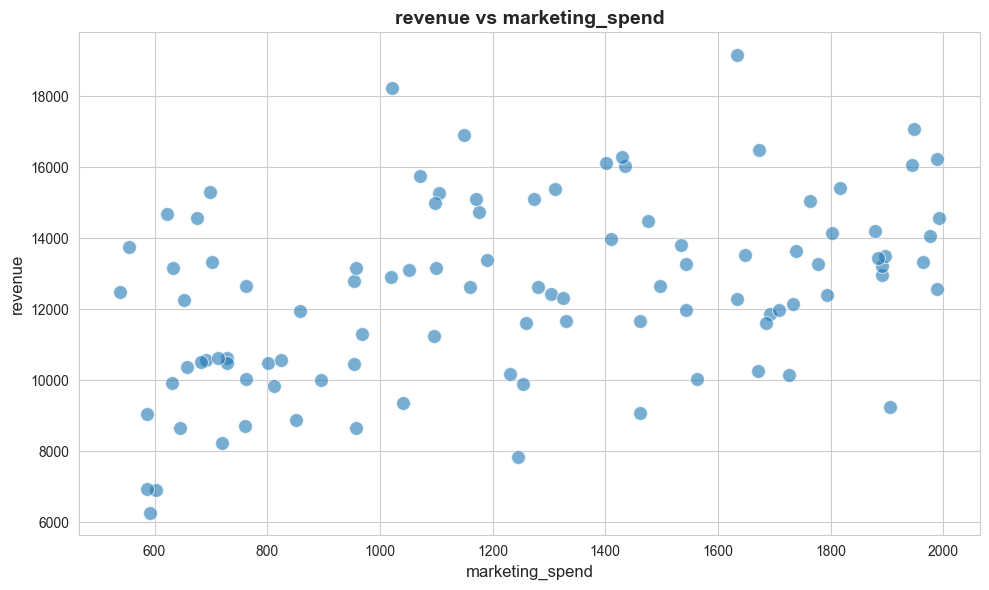

In [19]:
# Scatter plot with trend
dv_sales.plot_scatter('marketing_spend', 'revenue')

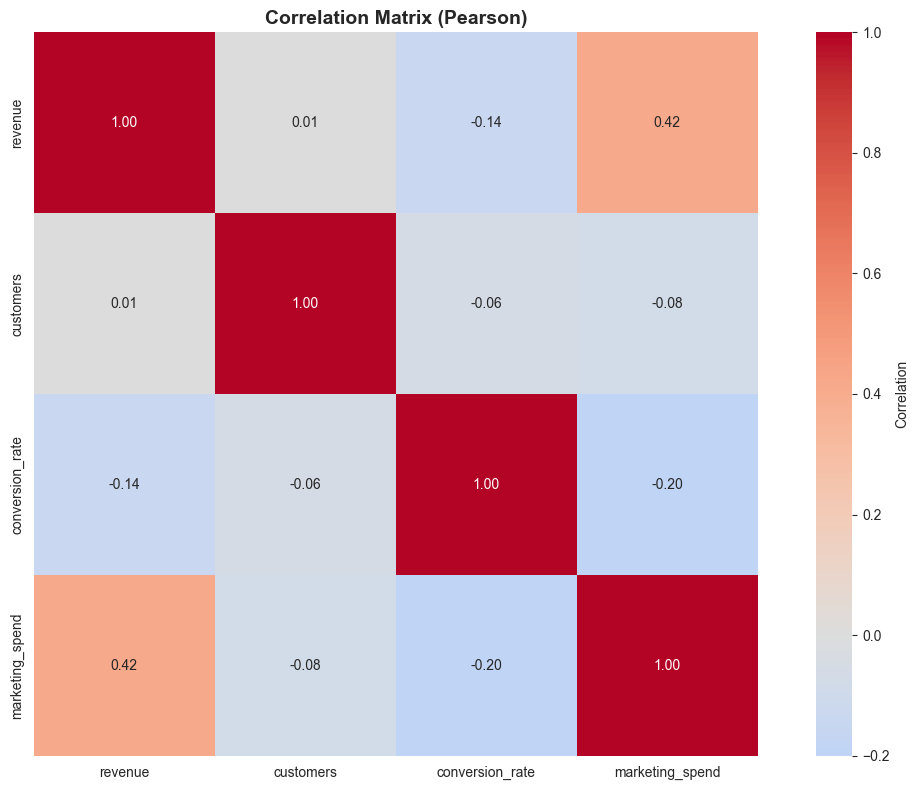

In [20]:
# Correlation heatmap
dv_sales.plot_correlation(method='pearson')

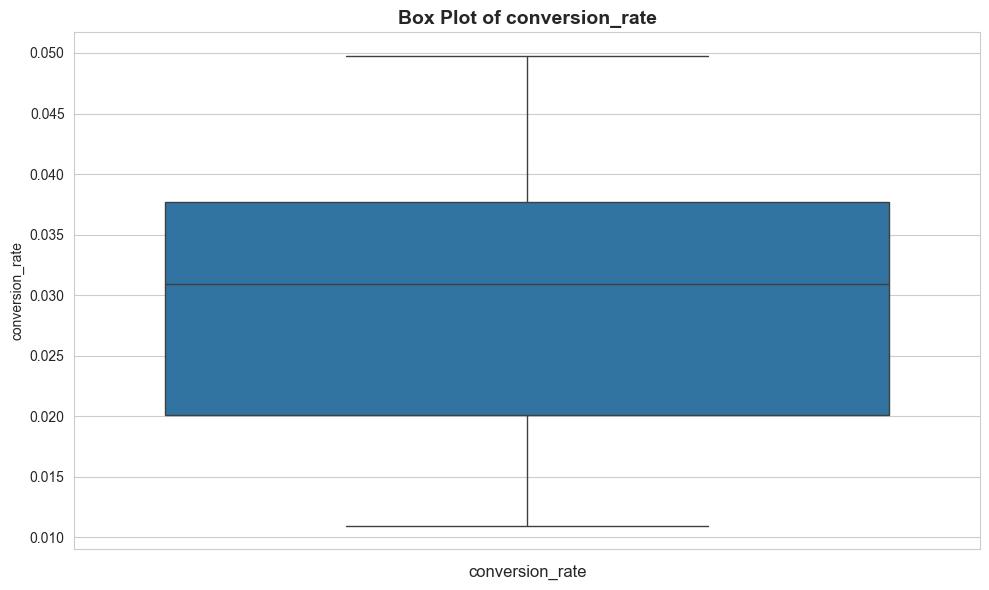

In [21]:
# Box plot for outlier detection
dv_sales.plot_distribution('conversion_rate', kind='box')

Categorical Data Visualization:


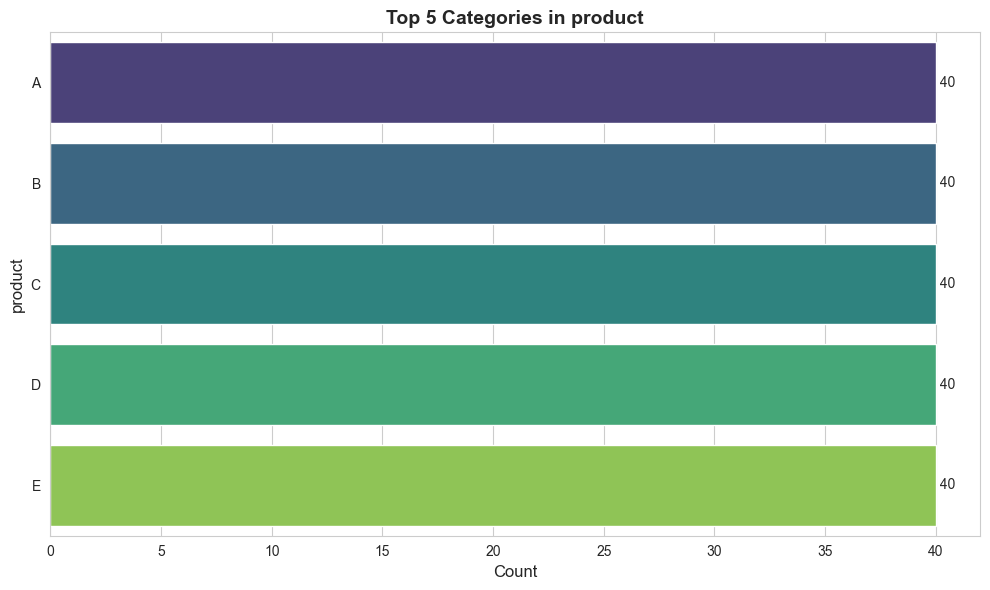

In [22]:
# Categorical Visualization
print("Categorical Data Visualization:")

# Bar chart for product categories
dv.plot_categorical('product', top_n=5)

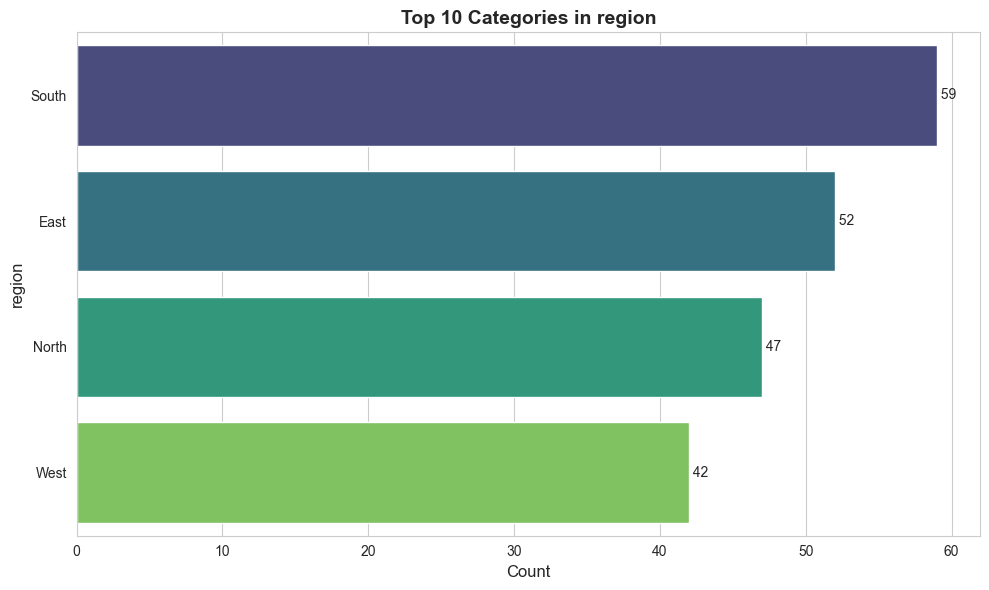

In [23]:
# Bar chart for regions
dv.plot_categorical('region')

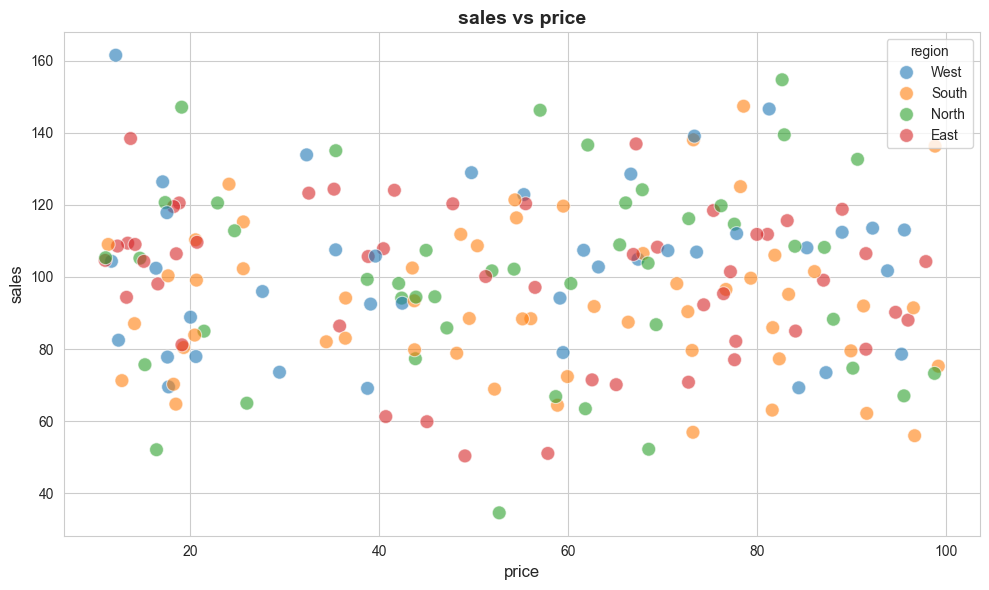

Comparing different regions:

West Region:
  Average Sales: $103.36
  Average Rating: 3.01
  Total Quantity: 1084

South Region:
  Average Sales: $93.24
  Average Rating: 3.09
  Total Quantity: 1329

North Region:
  Average Sales: $100.43
  Average Rating: 3.00
  Total Quantity: 1177

East Region:
  Average Sales: $99.55
  Average Rating: 2.73
  Total Quantity: 1195


In [24]:
# Scatter with categorical hue
dv.plot_scatter('price', 'sales', hue='region')
# Compare different subsets
print("Comparing different regions:")
for region in df['region'].unique():
    subset = df[df['region'] == region]
    print(f"\n{region} Region:")
    print(f"  Average Sales: ${subset['sales'].mean():.2f}")
    print(f"  Average Rating: {subset['rating'].mean():.2f}")
    print(f"  Total Quantity: {subset['quantity'].sum()}")

In [25]:
print("Comparing different regions:")
for region in df['region'].unique():
    subset = df[df['region'] == region]
    print(f"\n{region} Region:")
    print(f"  Average Sales: ${subset['sales'].mean():.2f}")
    print(f"  Average Rating: {subset['rating'].mean():.2f}")
    print(f"  Total Quantity: {subset['quantity'].sum()}")

Comparing different regions:

West Region:
  Average Sales: $103.36
  Average Rating: 3.01
  Total Quantity: 1084

South Region:
  Average Sales: $93.24
  Average Rating: 3.09
  Total Quantity: 1329

North Region:
  Average Sales: $100.43
  Average Rating: 3.00
  Total Quantity: 1177

East Region:
  Average Sales: $99.55
  Average Rating: 2.73
  Total Quantity: 1195


Pairplot for multivariate analysis:


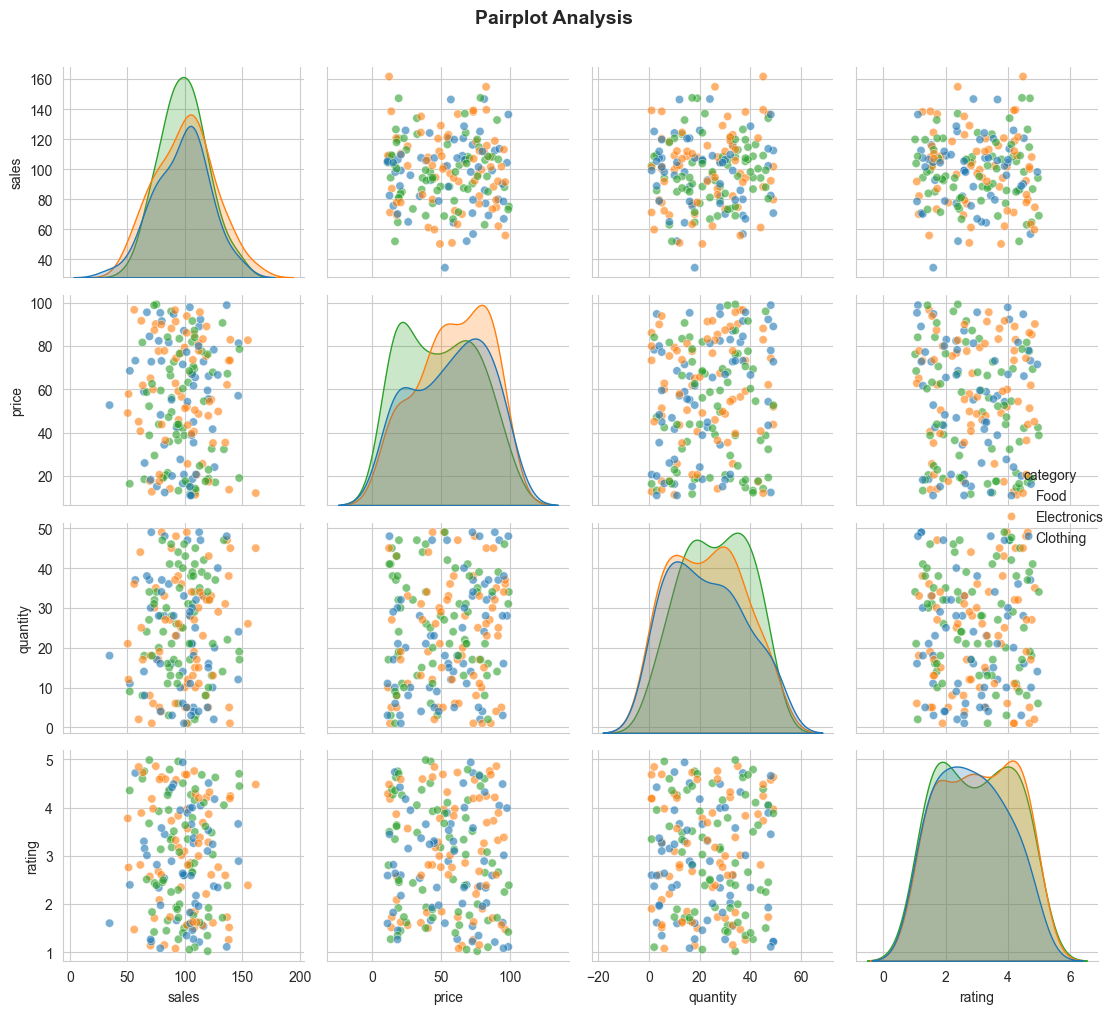

In [26]:
# Pairplot Analysis
print("Pairplot for multivariate analysis:")

# Select numeric columns for pairplot
dv.plot_pairplot(columns=['sales', 'price', 'quantity', 'rating'], hue='category')

In [28]:
# Use the pipeline

def analyze_dataset(dataframe, name="Dataset"):
    """Custom analysis function"""
    print(f"\n{'=' * 60}")
    print(f"ANALYSIS: {name}")
    print(f"{'=' * 60}")
    
    dv = DataViz(dataframe)
    dv.show()
    dv.insights()
    dv.visualize()
    
    return dv
    



ANALYSIS: Product Sales Data


,product,sales,price,quantity,region,rating,category
0,A,112.417854,88.963576,49,West,1.207294,Food
1,B,96.543392,76.669176,25,South,2.346417,Electronics
2,C,116.192213,72.731417,33,North,1.537659,Food
3,D,138.075746,73.223568,38,South,1.253500,Electronics
4,E,94.146166,42.354204,6,North,4.959841,Clothing
5,A,94.146576,36.423266,44,South,2.289415,Clothing
6,B,139.480320,82.842504,45,North,4.239498,Electronics
7,C,NaN,82.910206,32,North,2.018563,Food
8,D,88.263140,88.036509,45,North,3.726011,Electronics
9,E,113.564001,92.191650,47,West,4.040911,Food


🎨 Generating Automatic Visualizations...

📊 Correlation Heatmap


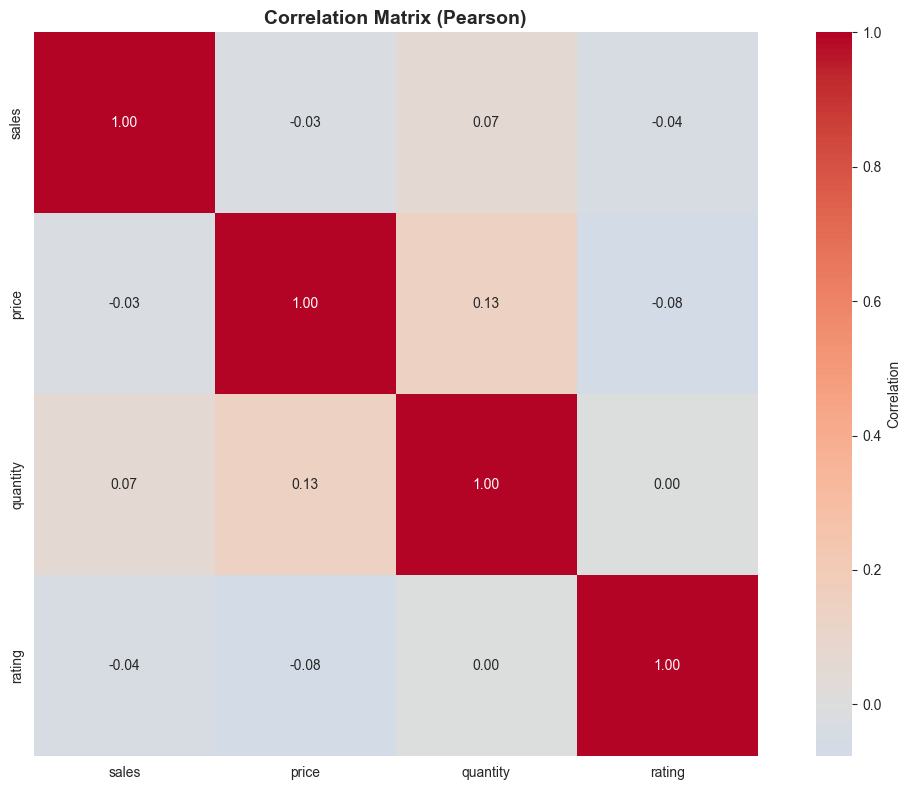

📊 Distribution of sales


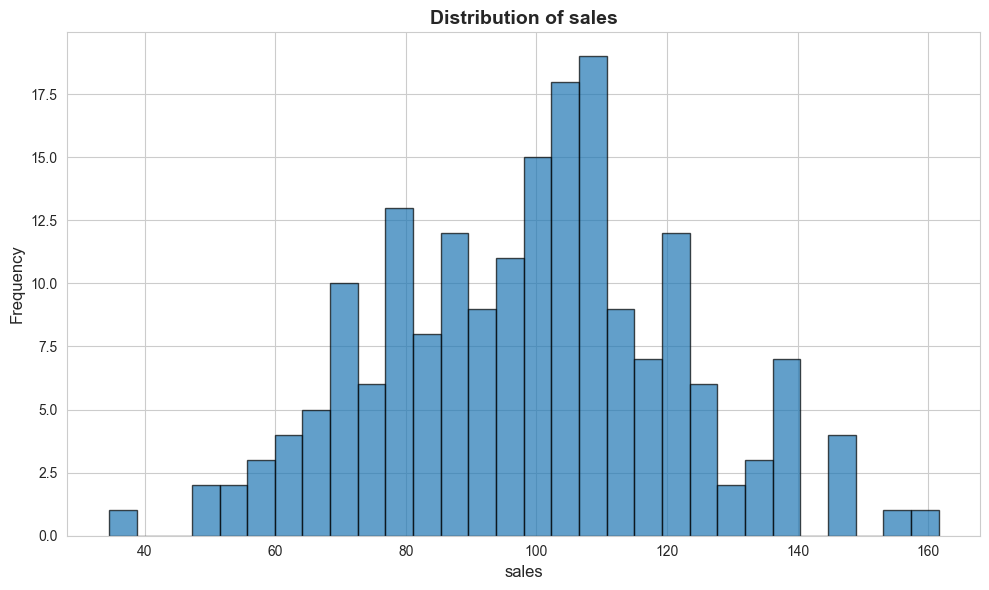

📊 Distribution of price


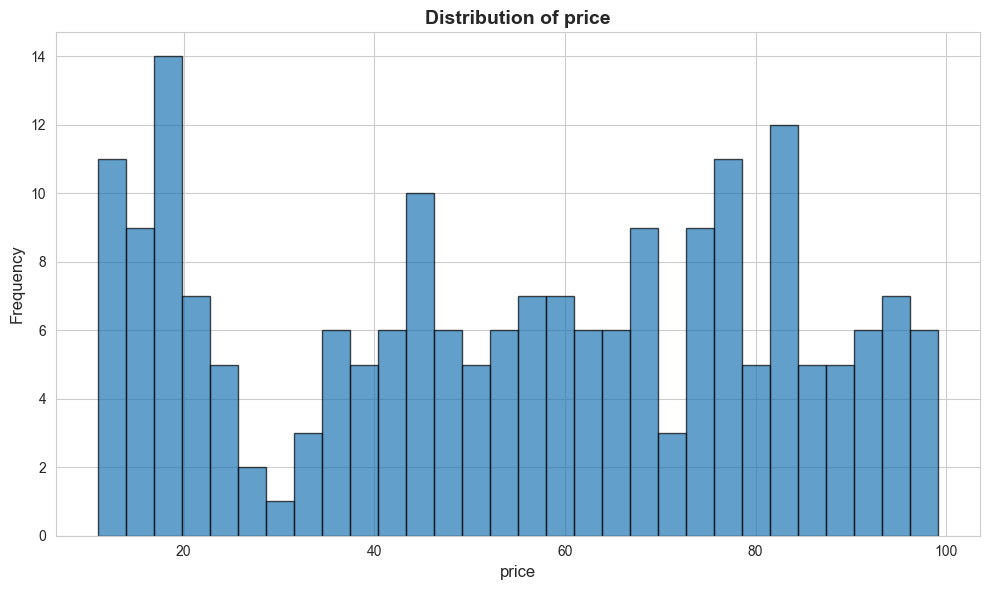

📊 Category Distribution of product


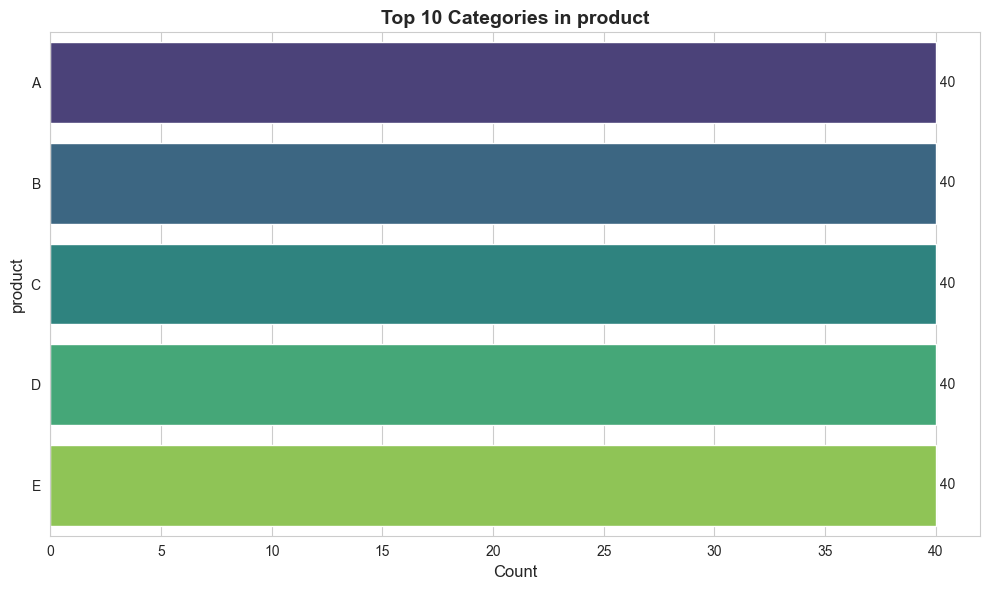

📊 Category Distribution of region


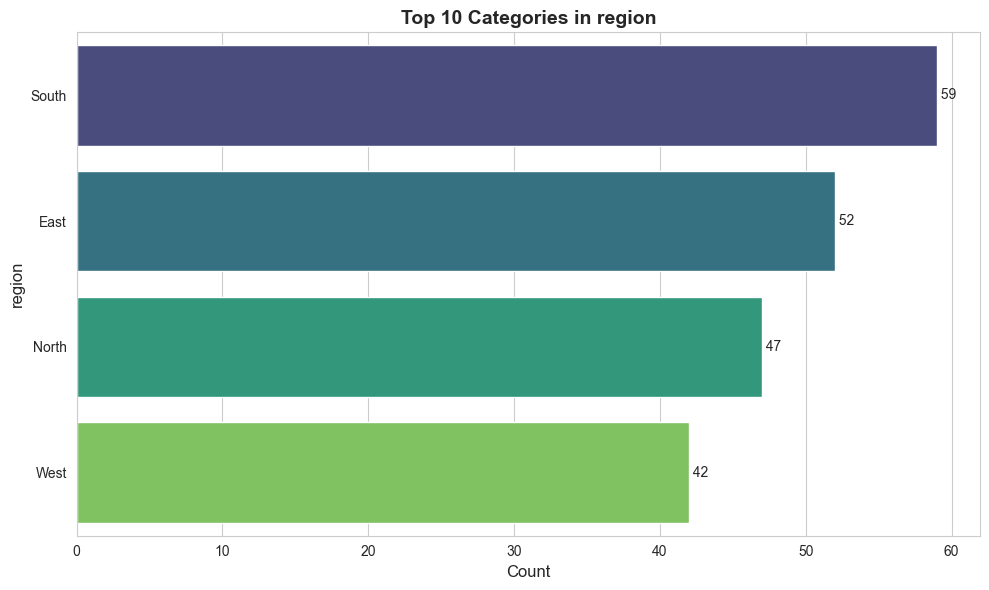

📊 Scatter Plot - price vs quantity


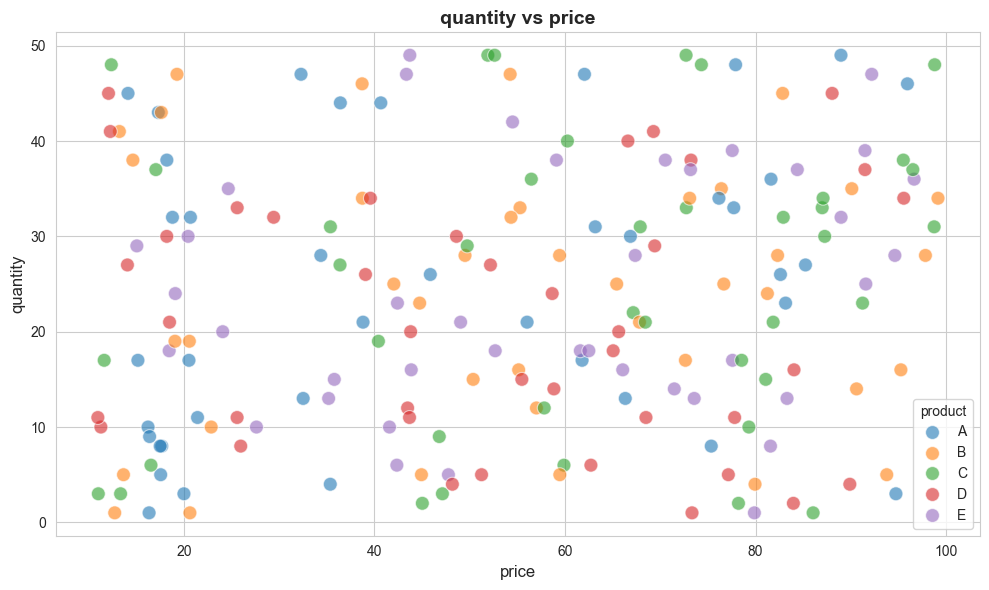

📊 Pairplot Analysis


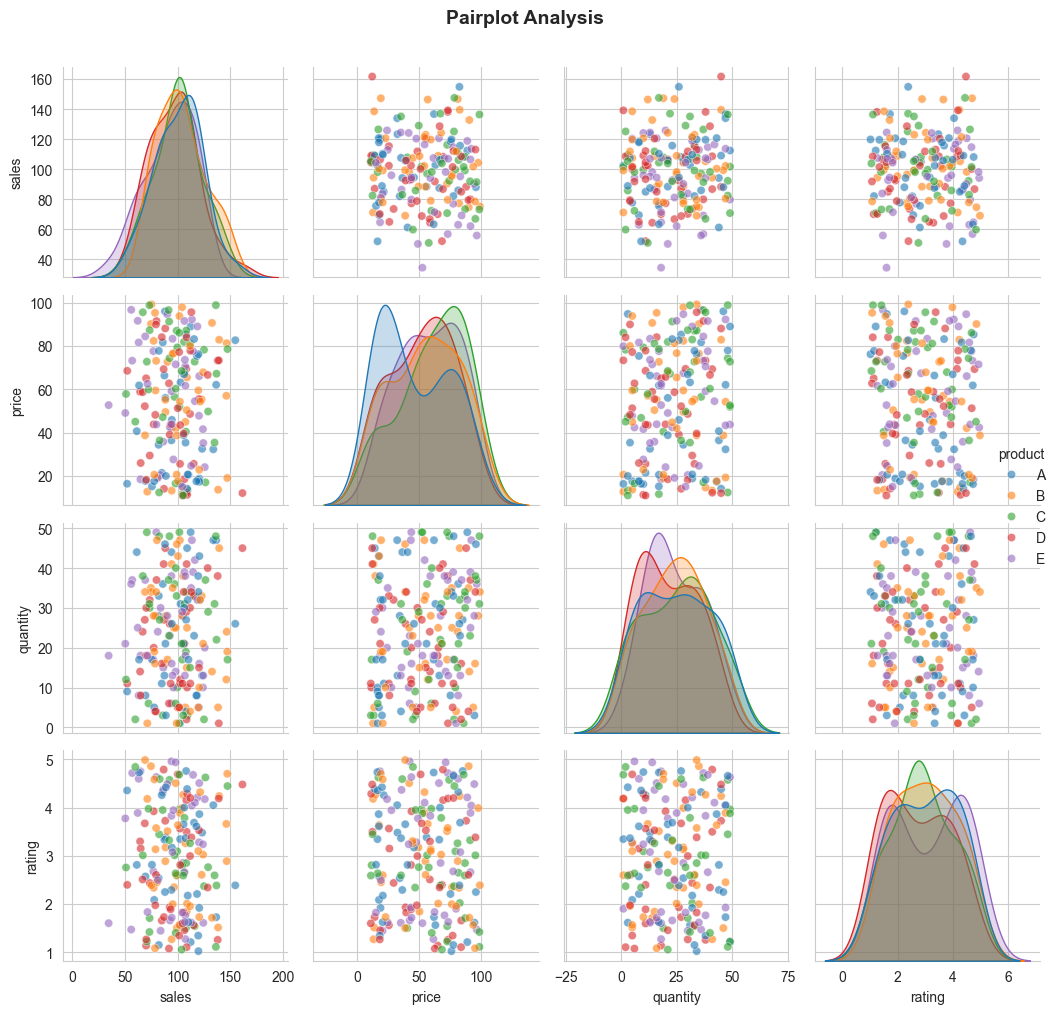


✅ Visualization complete!


In [29]:
result = analyze_dataset(df, "Product Sales Data")

In [30]:
def extract_insights_data(dv_obj):
    """Extract insights as structured data"""
    insights_list = []
    
    # Basic stats
    insights_list.append({
        'metric': 'row_count',
        'value': dv_obj.df.shape[0]
    })
    insights_list.append({
        'metric': 'column_count',
        'value': dv_obj.df.shape[1]
    })
    
    # Missing values
    missing = dv_obj.df.isnull().sum()
    for col in missing[missing > 0].index:
        insights_list.append({
            'metric': f'missing_{col}',
            'value': missing[col]
        })
    
    return pd.DataFrame(insights_list)

insights_df = extract_insights_data(dv)
print("Extracted Insights:")
print(insights_df)

Extracted Insights:
           metric  value
0       row_count    200
1    column_count      7
2   missing_sales     10
3  missing_rating      5


In [31]:
# Example of processing multiple datasets
datasets = {
    'Sales': df,
    'Marketing': sales_data,
}

print("Batch Analysis Report")
print("=" * 60)

for name, data in datasets.items():
    print(f"\n{name}:")
    dv_temp = DataViz(data)
    print(f"  Rows: {dv_temp.df.shape[0]}")
    print(f"  Columns: {dv_temp.df.shape[1]}")
    print(f"  Missing: {dv_temp.df.isnull().sum().sum()}")


Batch Analysis Report

Sales:
  Rows: 200
  Columns: 7
  Missing: 15

Marketing:
  Rows: 100
  Columns: 5
  Missing: 0


In [32]:
# Integration with Pandas
print("Pandas Integration Example:")
print(f"Original shape: {dv.df.shape}")

# Apply pandas operations
dv.df['profit'] = dv.df['sales'] - (dv.df['price'] * 0.6)
dv.df['profit_margin'] = dv.df['profit'] / dv.df['sales']

print(f"After adding columns: {dv.df.shape}")
dv.insights()

Pandas Integration Example:
Original shape: (200, 7)
After adding columns: (200, 9)
